In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from collections import defaultdict
from scipy import stats
from scipy.spatial.distance import mahalanobis
from pathlib import Path

/misc/team2/wenzel/mamba/envs/lamah-ce_lstm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Specify the time periods.

In [3]:
discharge_coverage_path = Path("~/BA/data/processed_data/eda/discharge_coverage.pkl")

discharge_coverage = pd.read_pickle(discharge_coverage_path)

##### Visualize normal periods for a subsample of basins. 

Basin 55 is the odd one out, it shows systematic gaps, and is therefore not usable.

In [4]:
min_normal_len = 1 

In [5]:
#fig, ax = plt.subplots(figsize=(10, len(discharge_coverage) * 0.25))

yticks = []
yticklabels = []

# Test pickling. 
train_dict = defaultdict(dict)
val_dict = defaultdict(dict)
test_dict = defaultdict(dict)

for basin in discharge_coverage.itertuples():

    basin_dict = {
        "start_dates": [],
        "end_dates" : []
    }
    normal_periods = []

    for period in basin[-2]: 

        x_min = period[0]
        x_width = (period[1] - period[0])

        if x_width.days > min_normal_len: 
            normal_periods.append((x_min,x_width))

            # Attach for pickling. 
            basin_dict["start_dates"].append(period[0])
            basin_dict["end_dates"].append(period[1])

    #ax.broken_barh(xranges=normal_periods, yrange=(len(yticks), 0.5))

    basin_id = basin[0]

    if len(basin_dict["end_dates"]) != 0: 

        if basin_id < 600:
            train_dict[str(basin_id)] = basin_dict
        elif basin_id < 750: 
            val_dict[str(basin_id)] = basin_dict
        else: 
            test_dict[str(basin_id)] = basin_dict

    #yticks.append(len(yticks))
    #yticklabels.append(basin[0])

#ax.set_yticks(yticks)
#ax.set_yticklabels(yticklabels)
#ax.set_ylim(-1,len(yticks)+1)
#
#plt.tight_layout()
#plt.show()


In [6]:
n_samples = 0

for basin in discharge_coverage["q5_q95_normal_periods"]: 

    for period in basin: 

        duration = (period[1] - period[0]).days

        if duration >= min_normal_len:
            n_samples += duration

print(n_samples)

9391290


#### Specify the basin IDs.

In [7]:
# Remove NA & non-numeric columns and normalize with z-score for PCA.

scaler = preprocessing.StandardScaler()

# Load attributes and hydrologic indices.
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

# Drop Na and non-numeric columns, to prep for clustering.
no_na_attributes = basin_stca_gdf.dropna().sort_index()
numeric_attributes = no_na_attributes.select_dtypes(include=["number"])
scaled_attributes = pd.DataFrame(
    scaler.fit_transform(numeric_attributes.values),
    columns=numeric_attributes.columns,
    index=numeric_attributes.index
)

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
    scaler.fit_transform(numeric_hy_id.values),
    columns=numeric_hy_id.columns,
    index=numeric_hy_id.index
)

# Remove basins for which no hy_id exists. 
common_ids = scaled_attributes.index.intersection(scaled_hy_id.index)
scaled_attributes = scaled_attributes.loc[common_ids]
scaled_hy_id = scaled_hy_id.loc[common_ids]

Determine which features vary the most, as a argument for number of clusters. 

In [8]:
scaled_attributes.columns.get_loc(key="bedrk_dep")

34

In [9]:
scaled_attributes.iloc[:,:34].var().sort_values(ascending=False)

lake_fra      1.017109
area_calc     1.015959
mvert_dist    1.012406
elon_ratio    1.010419
slope_mean    1.006476
p_mean        1.005337
mvert_ang     1.005234
lc_dom        1.004252
elev_std      1.003496
elev_ran      1.003221
strm_dens     1.002463
lo_prec_fr    1.001265
urban_fra     1.000654
agr_fra       1.000291
hi_prec_fr    0.999635
hi_prec_du    0.999517
ndvi_min      0.996713
lo_prec_du    0.996316
eta_mean      0.995140
p_season      0.994832
arid_1        0.993037
frac_snow     0.992619
bare_fra      0.992362
forest_fra    0.989859
arid_2        0.986813
elev_med      0.986361
elev_mean     0.984850
lai_max       0.973132
lai_diff      0.972825
gvf_diff      0.966307
et0_mean      0.964454
ndvi_max      0.920056
gvf_max       0.912672
glac_fra      0.629705
dtype: float64

In [10]:
pca = PCA(n_components=0.9, svd_solver="full")
pca_attributes = pca.fit_transform(scaled_attributes)

In [11]:
len(pca.explained_variance_ratio_)

21

/misc/team2/wenzel/mamba/envs/lamah-ce_lstm/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


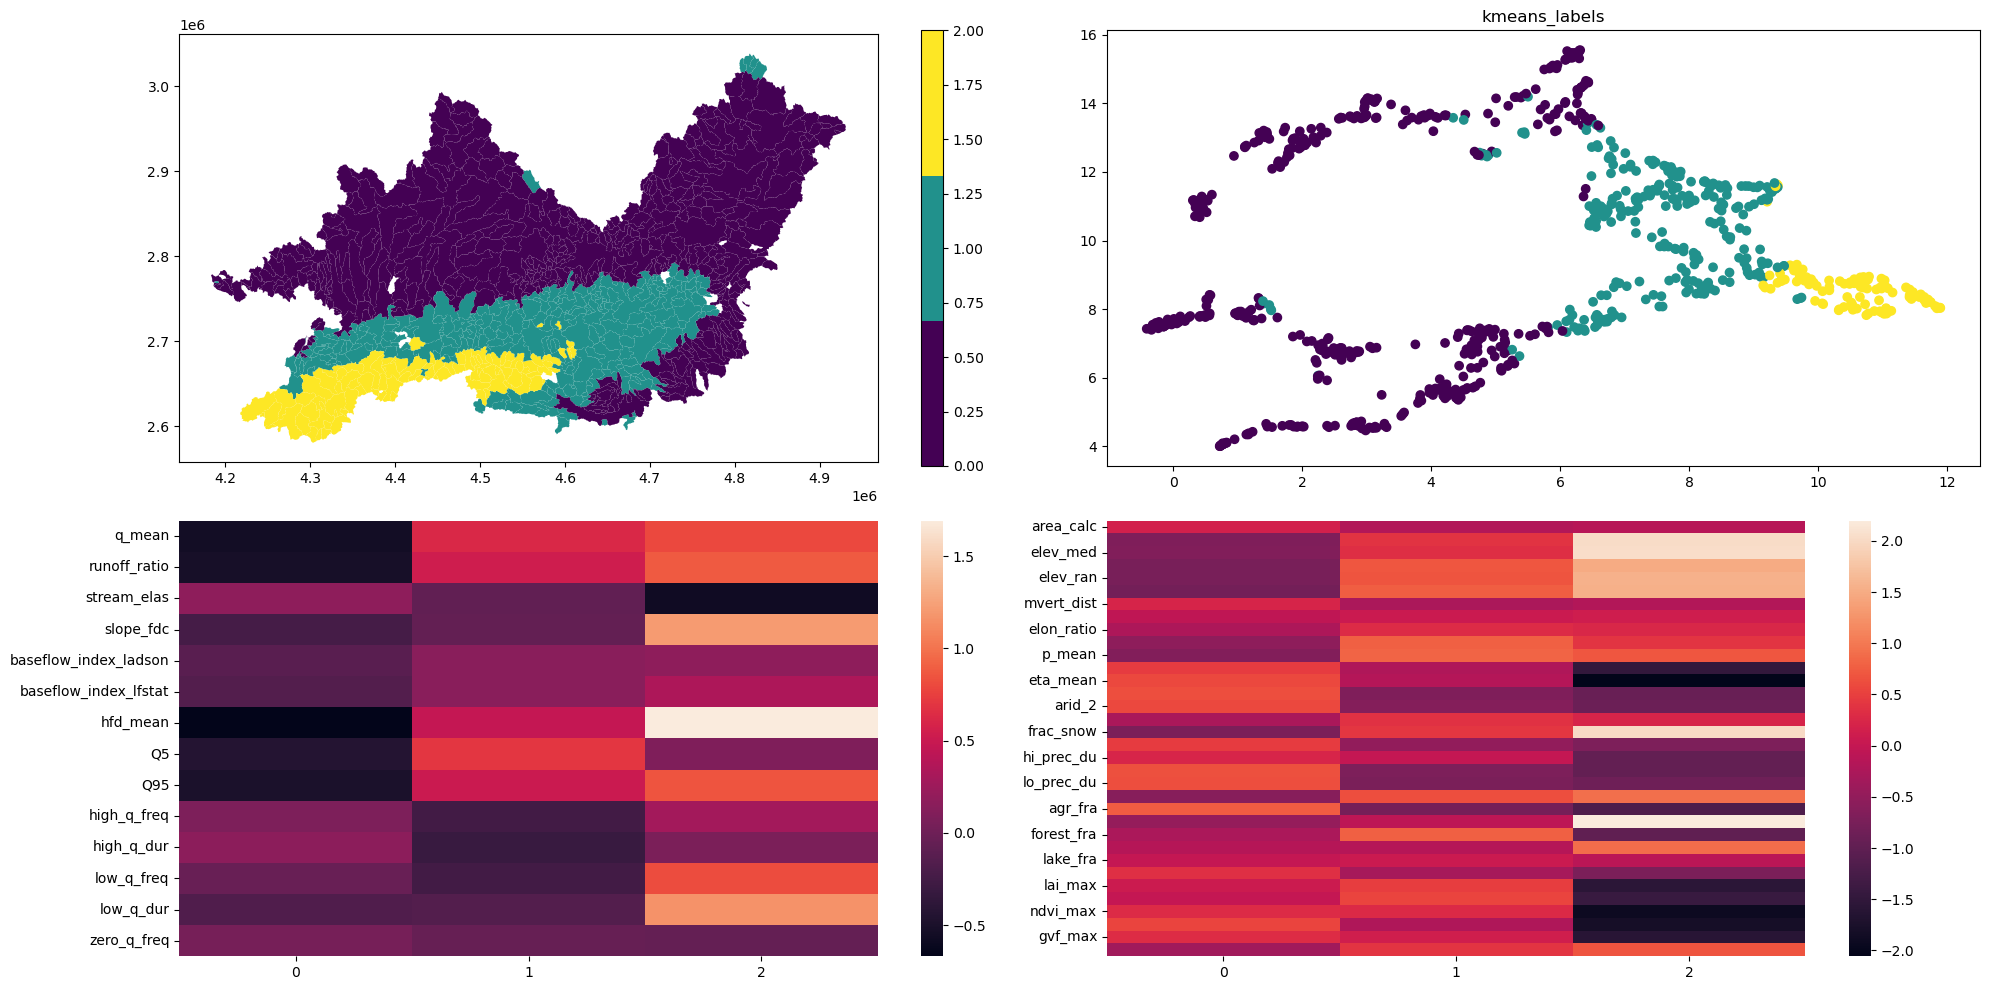

In [12]:
n_clusters = 3
seed = 4 

# KMEANS
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)

# Fit on normal basins. 
kmeans_labels = pd.Series(kmeans.fit_predict(pca_attributes), scaled_attributes.index)

# PLOT
plot_gdf = no_na_attributes.loc[common_ids].copy()
plot_gdf["kmeans_labels"] = kmeans_labels

# Assign one fix color for each cluster
cmap = mpl.colormaps["viridis"].resampled(n_clusters)
vmin = plot_gdf["kmeans_labels"].min()
vmax = plot_gdf["kmeans_labels"].max()

fig, axs = plt.subplots(2,2,figsize=(20,10))

plot_gdf.plot(
    ax=axs[0,0],
    column="kmeans_labels",
    cmap=cmap, vmin=vmin, vmax=vmax,
    legend=True)

reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
)

umap2d = reducer.fit_transform(pca_attributes)
plot_gdf[["UMAP1","UMAP2"]] = umap2d

axs[0,1].scatter(plot_gdf["UMAP1"], plot_gdf["UMAP2"], c=kmeans_labels)

axs[0,1].set_title("kmeans_labels")


# Calculate mean values of hydro id per cluster group.
hy_id_mean_df = scaled_hy_id.groupby(kmeans_labels).mean()

sns.heatmap(ax=axs[1,0],data = scaled_hy_id.groupby(kmeans_labels).mean().transpose())
sns.heatmap(ax=axs[1,1], data = scaled_attributes.iloc[:,:34].groupby(kmeans_labels).mean().transpose())

plt.tight_layout()

In [15]:
kmeans_labels.value_counts()

0    459
1    277
2    105
Name: count, dtype: int64

Text(0.5, 1.0, 'DB_scores')

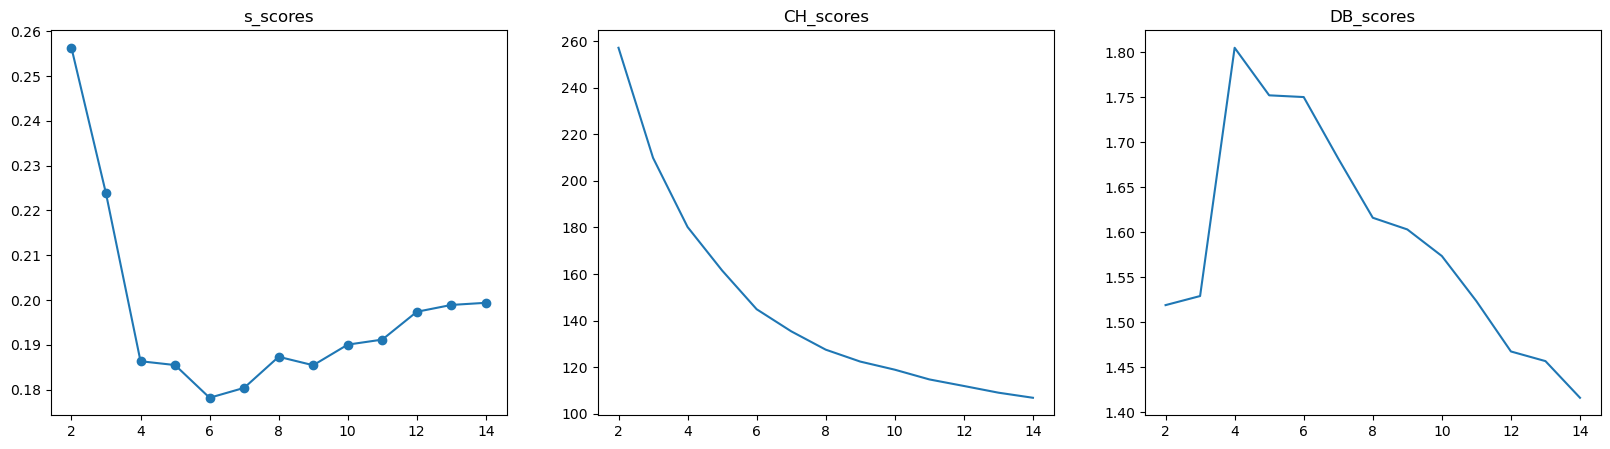

In [21]:
n_seeds = 10

seeds = [12312, 14535, 2345456, 23434, 346667, 7978, 45454, 72673, 6, 2562426] 


s_scores = np.zeros([n_seeds,15]) 
CH_scores =  np.zeros([n_seeds,15])
DB_scores =  np.zeros([n_seeds,15])

for i in range(0,n_seeds):

    seed = seeds[i]

    for k in range(2,15):

        # Test for k-means.
        labels = KMeans(k,random_state=seed).fit_predict(pca_attributes)
        s_scores[i,k] = silhouette_score(pca_attributes,labels) # higher is better
        CH_scores[i,k] = calinski_harabasz_score(pca_attributes,labels) # higher is better
        DB_scores [i,k] = davies_bouldin_score(pca_attributes, labels) # lower is better

avg_s_scores = s_scores.mean(axis=0)[2:]
avg_ch_scores = CH_scores.mean(axis=0)[2:]
avg_db_scores = DB_scores.mean(axis=0)[2:]

fig, axs = plt.subplots(1,3, figsize=(20,5))

axs[0].plot(range(2,15), avg_s_scores, marker="o")
axs[1].plot(range(2,15), avg_ch_scores)
axs[2].plot(range(2,15), avg_db_scores)

axs[0].set_title("s_scores")
axs[1].set_title("CH_scores")
axs[2].set_title("DB_scores")


In [32]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(random_state=42)

RF.fit(scaled_attributes, kmeans_labels)

feature_importances = pd.Series(RF.feature_importances_, index=scaled_attributes.columns)

In [33]:
feature_importances.sort_values(ascending=False)

slope_mean    0.119334
frac_snow     0.100729
elev_mean     0.082896
elev_med      0.080079
elev_ran      0.078192
elev_std      0.057847
soil_condu    0.044624
eta_mean      0.040490
arid_2        0.033568
agr_fra       0.031334
bare_fra      0.027401
bedrk_dep     0.022475
lo_prec_du    0.021584
sand_fra      0.020592
clay_fra      0.019507
silt_fra      0.018668
lai_max       0.016892
lo_prec_fr    0.015953
arid_1        0.012717
ndvi_max      0.011628
p_mean        0.011200
forest_fra    0.011160
soil_poros    0.010527
ndvi_min      0.010444
lc_dom        0.009112
strm_dens     0.008537
gvf_max       0.007891
et0_mean      0.006952
grav_fra      0.005811
lai_diff      0.005725
geol_poros    0.004845
glac_fra      0.004778
hi_prec_fr    0.004625
gc_sc_fra     0.004441
root_dep      0.004306
soil_tawc     0.003510
gvf_diff      0.003062
p_season      0.003033
geol_perme    0.002530
hi_prec_du    0.002237
gc_mt_fra     0.002134
elon_ratio    0.001944
gc_pa_fra     0.001756
mvert_dist 

Ask Bruno, if there exists a priori knowlegde of how many clusters there should be.

Heatmap suffices, no further statistical needed. 

Strong spatial autocorrelation --> convex cluster. 

regional modelling problem, ask Bruno. 

Export time periods as .pkl and basin id splits as .txt.

In [23]:
import pickle as pkl

splits_directory_path = Path("/home/wuhlmann/BA/data/processed_data/test_splits")

with open(splits_directory_path / "train.pkl", "wb") as out: 
    pkl.dump(train_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "val.pkl", "wb") as out: 
    pkl.dump(val_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "test.pkl", "wb") as out: 
    pkl.dump(test_dict, out, protocol=pkl.HIGHEST_PROTOCOL)


In [24]:
with open(splits_directory_path / "train_basin_ids.txt", "w") as f: 
    for id in train_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "val_basin_ids.txt", "w") as f: 
    for id in val_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "test_basin_ids.txt", "w") as f: 
    for id in test_dict.keys():
        f.write(f"{id}\n")